# Exploratory analysis of UPI transaction data, followed by a simple fraud-detection model.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import numpy as np

## 2. Load Data.

In [8]:
df=pd.read_csv(r"C:\Users\anand\Downloads\upi_transactions_2024.csv")
df.rename(columns={"amount (INR)":"amount"},inplace=True)

## 3. Preprocess Timestamps.

In [9]:
df["timestamp"]=pd.to_datetime(df["timestamp"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction id      250000 non-null  str           
 1   timestamp           250000 non-null  datetime64[us]
 2   transaction type    250000 non-null  str           
 3   merchant_category   250000 non-null  str           
 4   amount              250000 non-null  int64         
 5   transaction_status  250000 non-null  str           
 6   sender_age_group    250000 non-null  str           
 7   receiver_age_group  250000 non-null  str           
 8   sender_state        250000 non-null  str           
 9   sender_bank         250000 non-null  str           
 10  receiver_bank       250000 non-null  str           
 11  device_type         250000 non-null  str           
 12  network_type        250000 non-null  str           
 13  fraud_flag          250000 non-null  int

## 4. Preview DataQuick look at the raw dataframe.

In [5]:
df

,transaction id,timestamp,transaction type,merchant_category,amount,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TXN0000249996,2024-11-08 22:41:43,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,HDFC,iOS,5G,0,22,Friday,0
249996,TXN0000249997,2024-12-15 02:58:03,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,Yes Bank,Android,5G,0,2,Sunday,1
249997,TXN0000249998,2024-11-27 16:33:25,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,ICICI,Android,4G,0,16,Wednesday,0
249998,TXN0000249999,2024-01-05 13:31:30,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,ICICI,iOS,4G,0,13,Friday,0


## 5. Transaction Volume by Day & Hour Heatmap showing when transactions happen most across the week.

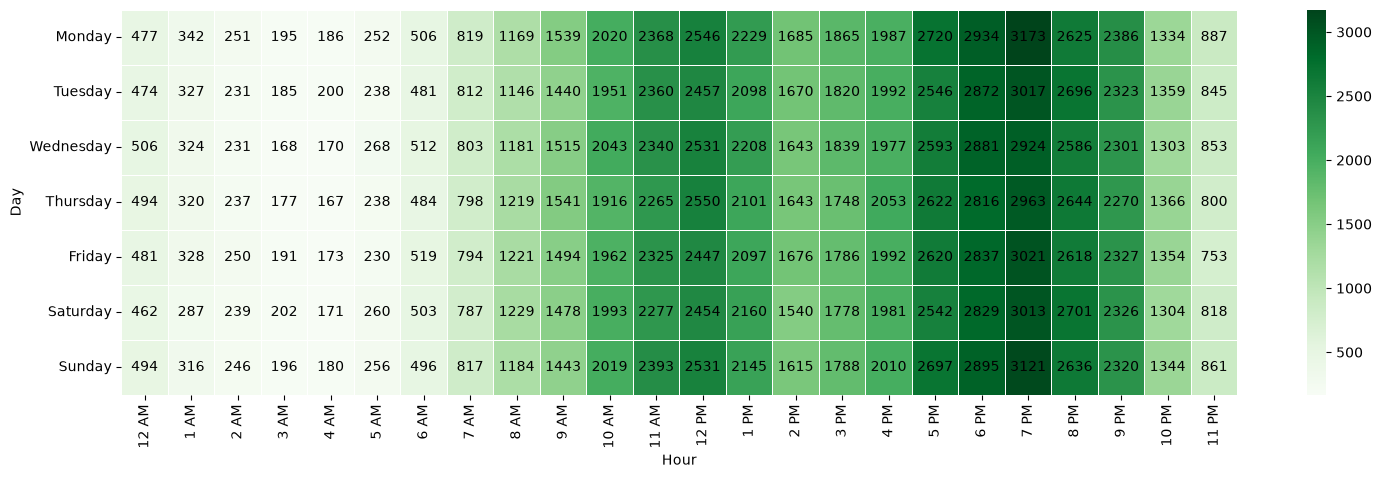

In [10]:
data=df[["timestamp","transaction id"]]
data["hour"]=data["timestamp"].dt.hour
data["day"]=data["timestamp"].dt.day_name()
table=data.pivot_table(index="day",columns="hour",values="transaction id",aggfunc="count")
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
table = table.reindex(day_order)

new_columns = []

for i in range(len(table.columns)):
    h = table.columns[i]

    if h < 12:
        if h == 0:
            new_columns.append("12 AM")
        else:
            new_columns.append(f"{h} AM")
    else:
        if h == 12:
            new_columns.append("12 PM")
        else:
            new_columns.append(f"{h - 12} PM")

table.columns = new_columns
plt.figure(figsize=(18,5))
sns.heatmap(table,annot=True,cmap="Greens",fmt="d",linewidths=0.5,linecolor="White",annot_kws={"color":"Black"})
plt.xticks(rotation=90)
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

## 6. Amount Distribution by Age Group.

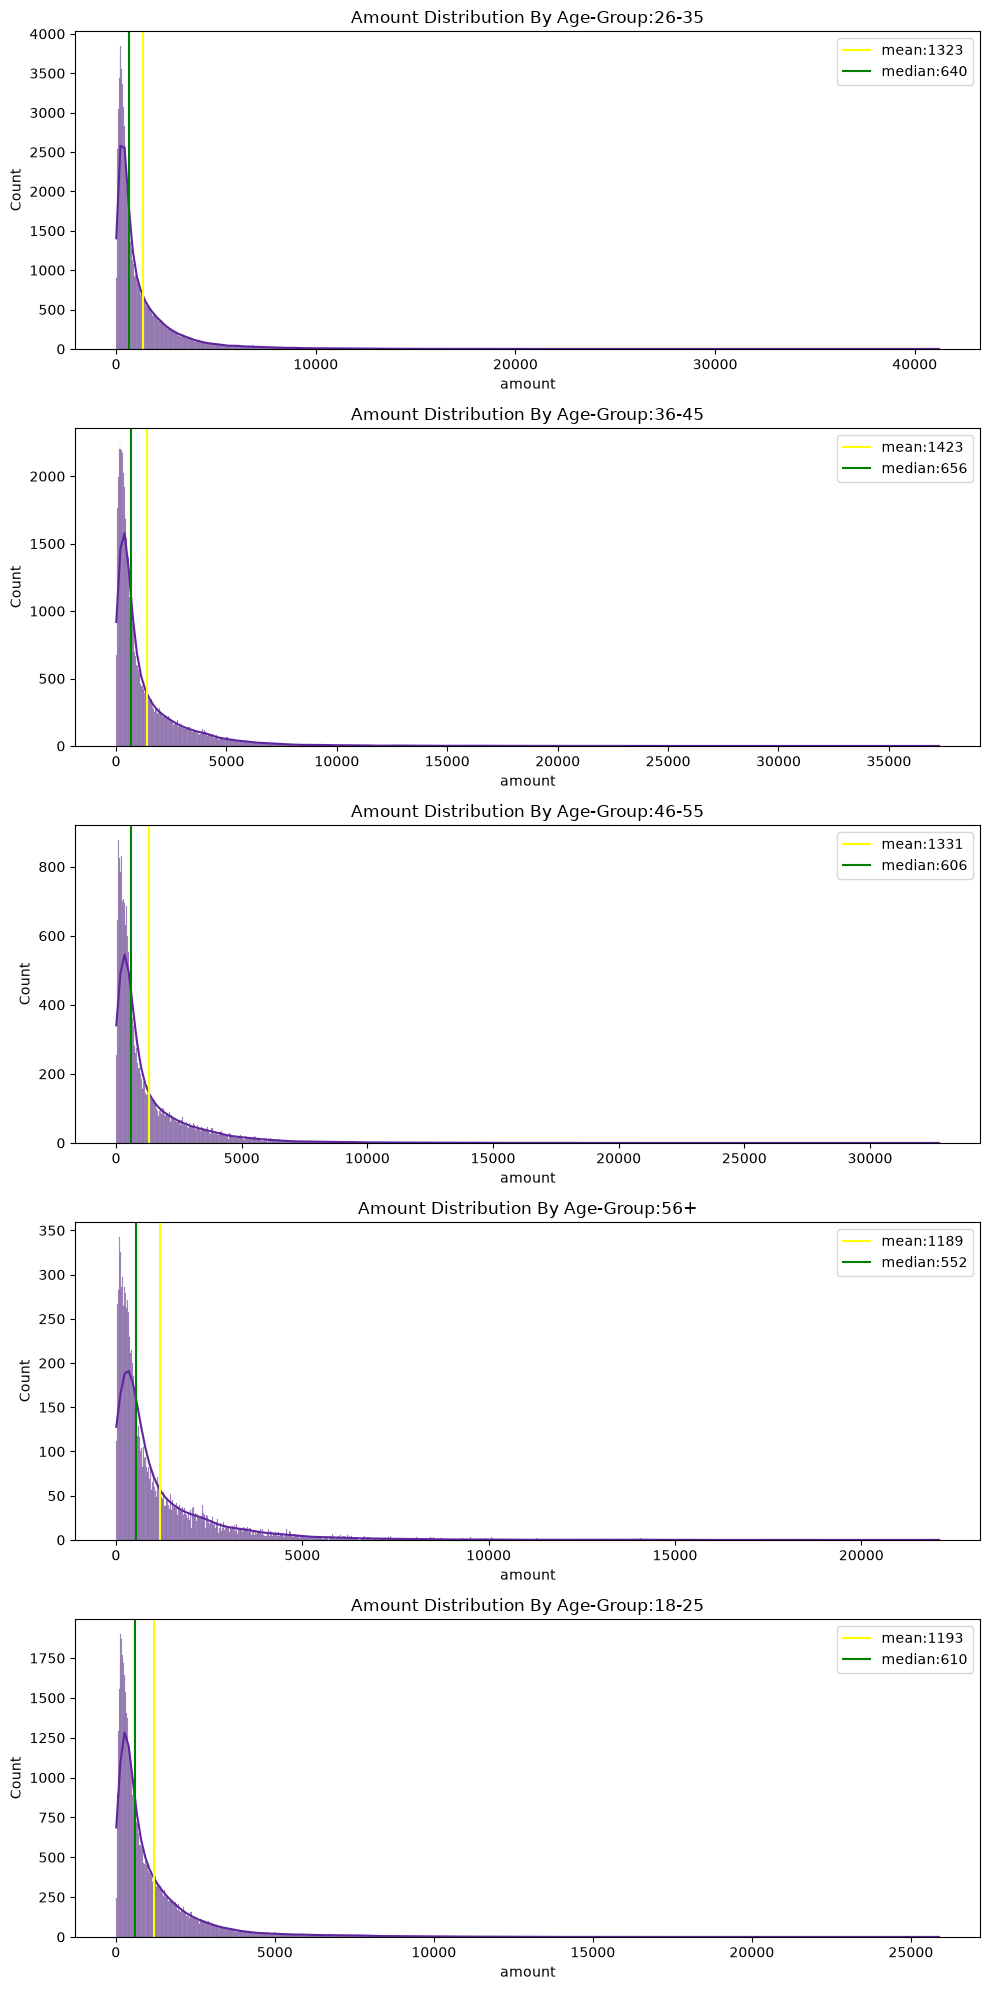

In [23]:
data=df[["amount","sender_age_group","transaction_status"]]
data=data[data["transaction_status"]=="SUCCESS"]
fig,axes=plt.subplots(len(data["sender_age_group"].unique()),1,figsize=(10,20))
def plot_by_age(group,ax):
    mean=round(group["amount"].mean())
    median=round(group["amount"].median())
    sns.histplot(group["amount"],bins=1000,color="#5F259F",kde=True,ax=ax)
    ax.axvline(mean,color="Yellow",label=f"mean:{mean}")
    ax.axvline(median,color="Green",label=f"median:{median}")
    ax.legend()
    ax.set_title(f"Amount Distribution By Age-Group:{group['sender_age_group'].unique()[0]}")
for i in range(len(data["sender_age_group"].unique())):
    group=data[(data["sender_age_group"]==data["sender_age_group"].unique()[i]) & (data["transaction_status"]=="SUCCESS")]
    plot_by_age(group,axes[i])
plt.tight_layout()

## 7. Amount Distribution by Merchant Category.

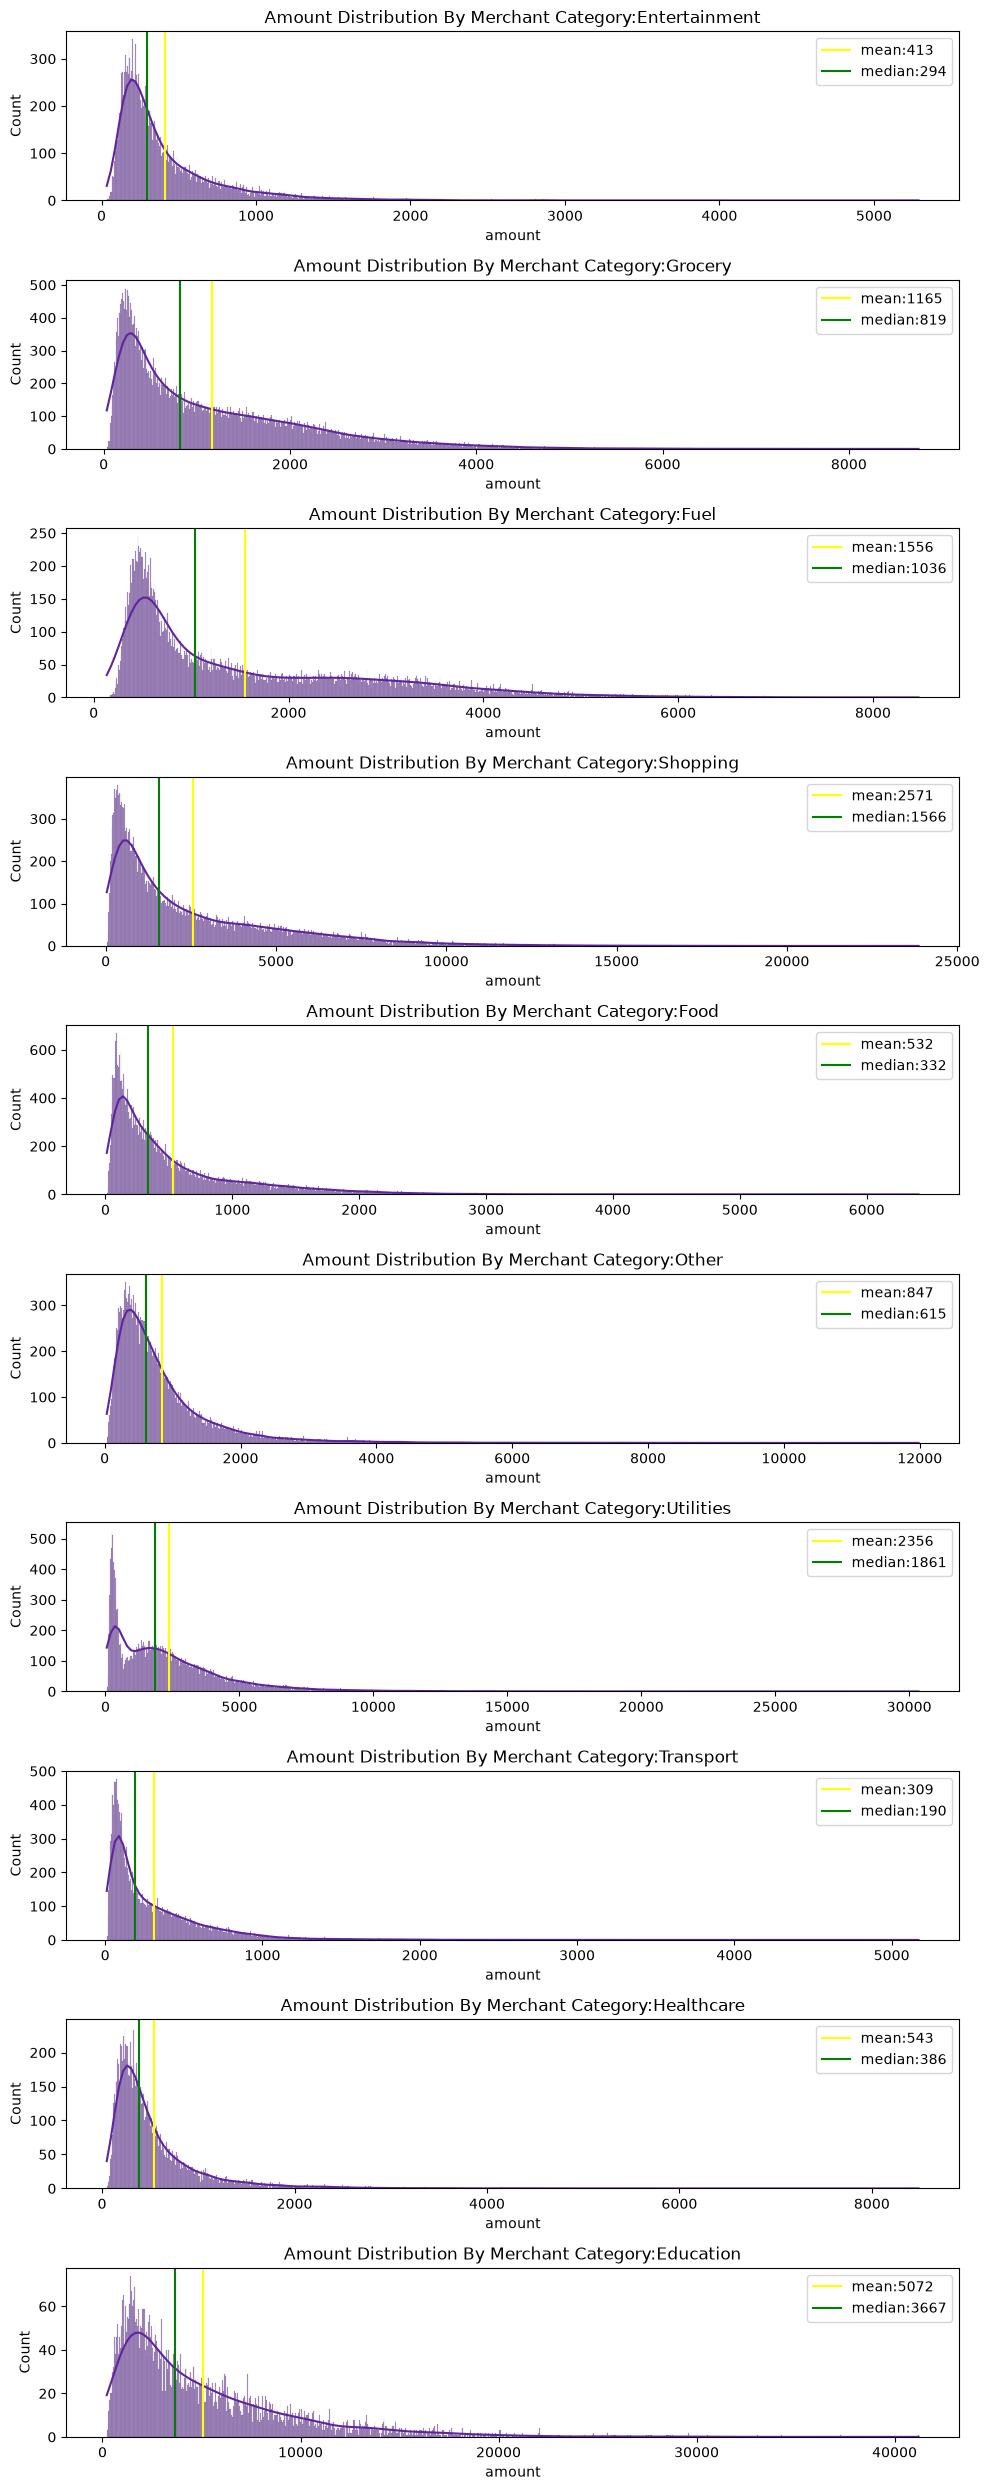

In [13]:
data=df[["amount","merchant_category","transaction_status"]]
data=df[df["transaction_status"]=="SUCCESS"]
data.rename(columns={"merchant_category":"category"},inplace=True)
fig,axes=plt.subplots(len(data["category"].unique()),1,figsize=(10,25))
def plot_by_category(group,ax):
    mean=round(group["amount"].mean())
    median=round(group["amount"].median())
    sns.histplot(group["amount"],bins=1000,color="#5F259F",kde=True,ax=ax)
    ax.axvline(mean,color="Yellow",label=f"mean:{mean}")
    ax.axvline(median,color="Green",label=f"median:{median}")
    ax.set_title(f"Amount Distribution By Merchant Category:{group["category"].unique()[0]}")
    ax.legend()
    
for i in range(len(data["category"].unique())):
    group=data[(data["category"]==data["category"].unique()[i]) &(data["transaction_status"]=="SUCCESS")]
    plot_by_category(group,axes[i])

plt.tight_layout()

## 8. Total Spend by Merchant Category.

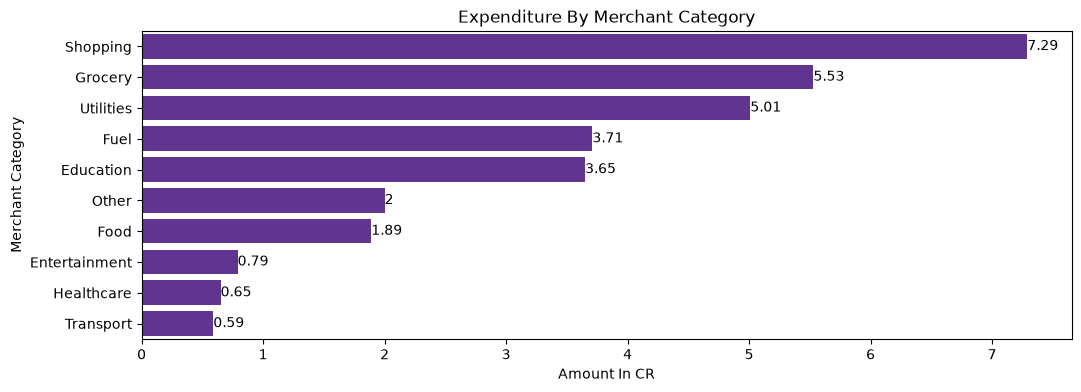

In [14]:
data=df[["amount","merchant_category","transaction_status"]]
data=data[data["transaction_status"]=="SUCCESS"]
data=data.groupby(["merchant_category"])["amount"].sum().div(1e7).round(2).sort_values(ascending=False)
plt.figure(figsize=(12,4))
ax=sns.barplot(y=data.index,x=data.values,color="#5F259F")
ax.bar_label(ax.containers[0])
plt.title("Expenditure By Merchant Category")
plt.xlabel("Amount In CR")
plt.ylabel("Merchant Category")
plt.show()

## 9. Total Amount by Transaction Type.

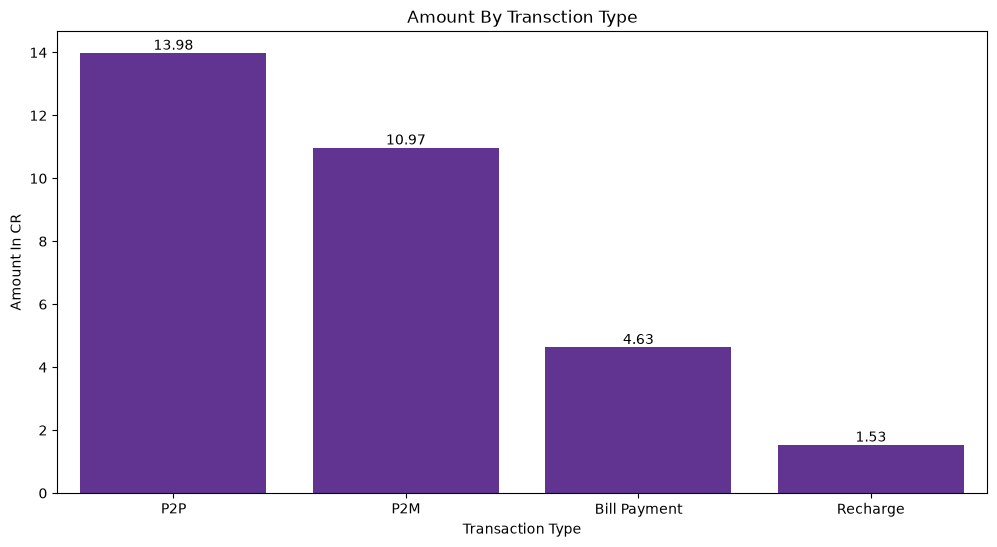

In [15]:
data=df[["amount","transaction type","transaction_status"]]
data=data[data["transaction_status"]=="SUCCESS"]
data=data.groupby("transaction type")["amount"].sum().div(1e7).round(2).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
ax=sns.barplot(x=data.index,y=data.values,color="#5F259F")
plt.title("Amount By Transction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount In CR")
ax.bar_label(ax.containers[0])
plt.show()

## 10. In-Bank vs Cross-Bank Transactions Count.

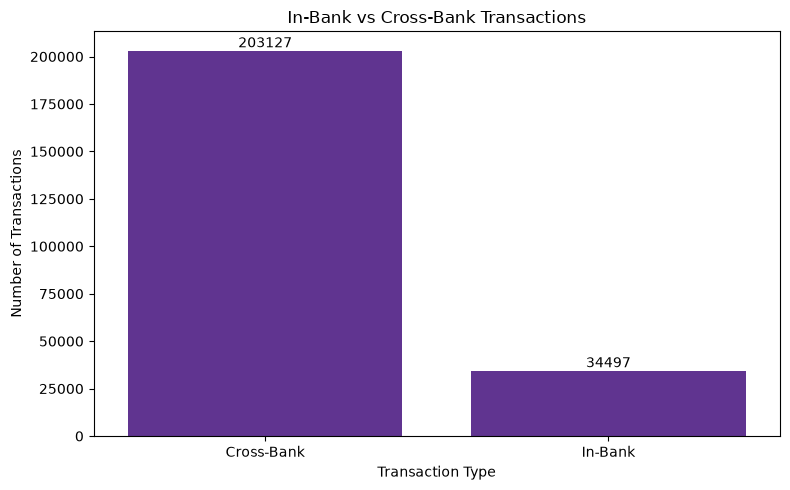

In [18]:
data = df[["amount", "sender_bank", "receiver_bank", "transaction_status"]]
data = data[data["transaction_status"] == "SUCCESS"]
data["transaction_type"] = np.where(
    data["sender_bank"] == data["receiver_bank"],
    "In-Bank",
    "Cross-Bank"
)
counts = data["transaction_type"].value_counts()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values,color="#5F259F")
plt.title("In-Bank vs Cross-Bank Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 11. Payment Failures by Device Type. Which device types see the most failures.

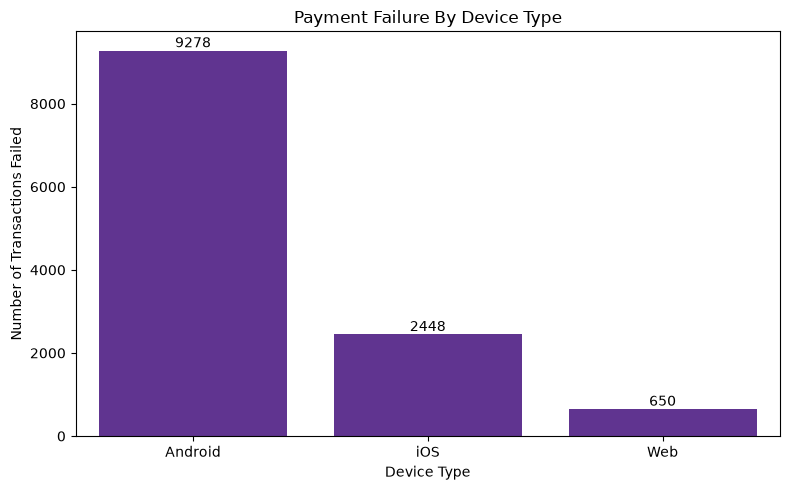

In [19]:
data = df[["transaction id", "device_type", "transaction_status"]]
data = data[data["transaction_status"] != "SUCCESS"]
data=data.groupby("device_type")["transaction id"].count().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=data.index, y=data.values,color="#5F259F")
plt.title("Payment Failure By Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions Failed")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 12. Payment Failures by Network Type. Which network types (WiFi/4G/5G etc.) see the most failures.

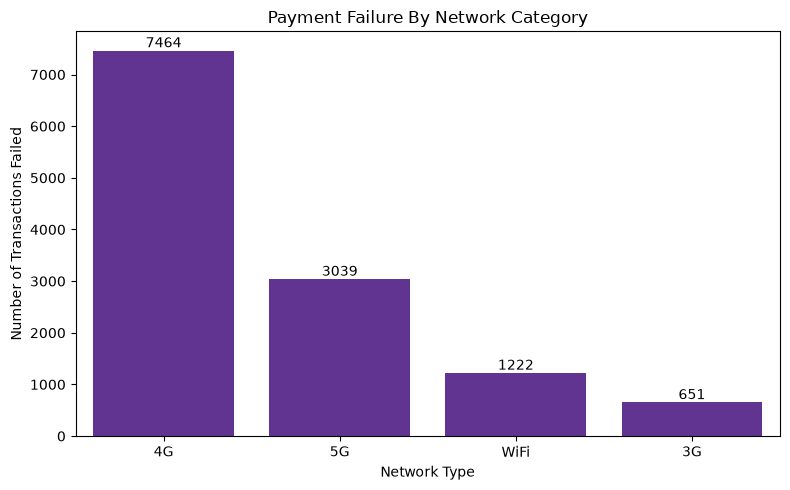

In [20]:
data = df[["transaction id", "network_type", "transaction_status"]]
data = data[data["transaction_status"] != "SUCCESS"]
data=data.groupby("network_type")["transaction id"].count().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=data.index, y=data.values,color="#5F259F")
plt.title("Payment Failure By Network Category")
plt.xlabel("Network Type")
plt.ylabel("Number of Transactions Failed")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 13. Transaction Amount by State.

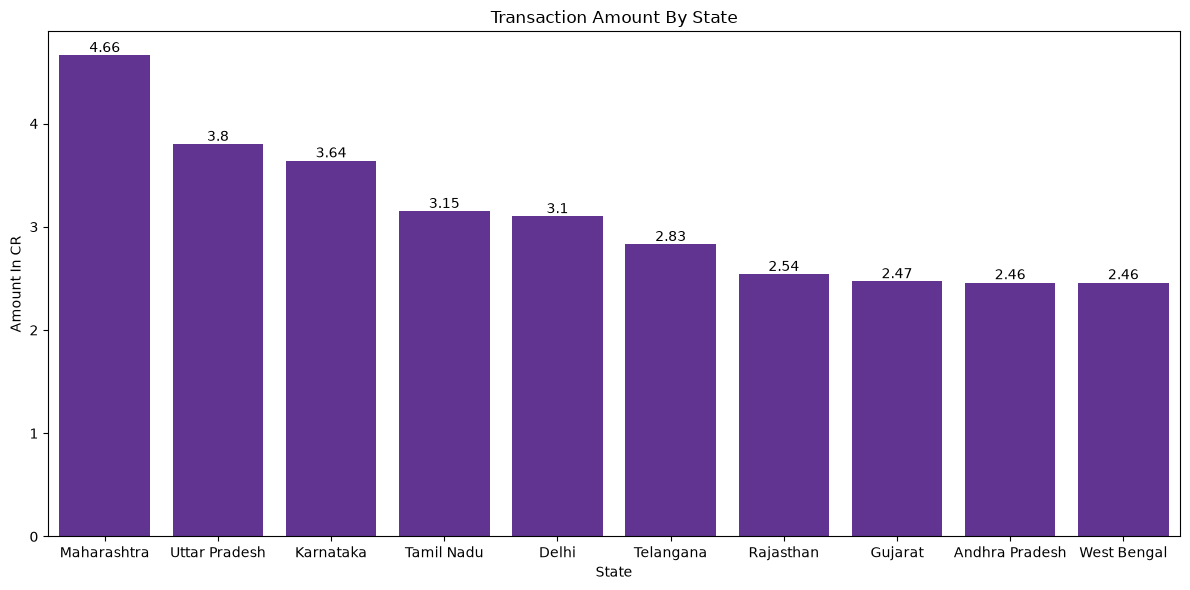

In [21]:
data=df[["amount","sender_state","transaction_status"]]
data=data[data["transaction_status"]=="SUCCESS"]
data=data.groupby("sender_state")["amount"].sum().div(1e7).round(2).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
ax=sns.barplot(x=data.index,y=data.values,color="#5F259F")
plt.title("Transaction Amount By State")
plt.xlabel("State")
plt.ylabel("Amount In CR")
ax.bar_label(ax.containers[0])
plt.tight_layout()

## 14. Fraud Detection ModelLogistic regression baseline predicting `fraud_flag` from amount, age group, hour, and day of week — includes threshold tuning via precision/recall/F1.

X_train shape: (200000, 14)
X_test shape : (50000, 14)

Intercept:
[-4.78791029]

Coefficients:
[[ 5.18204198e-05  4.42590377e-03 -6.95772188e-01 -9.20483554e-01
  -1.20603625e+00 -1.23271243e+00 -6.61062962e-01 -8.28701016e-01
  -6.95591449e-01 -6.05389300e-01 -6.10372991e-01 -6.19988101e-01
  -8.59415827e-01 -4.96608703e-01]]

First 5 fraud probabilities:
[0.00195628 0.00190766 0.00149787 0.00264626 0.00150323]

Confusion Matrix - Threshold 0.5:
[[49904     0]
 [   96     0]]

Best Threshold:
0.0026019967885775454

Best F1 Score:
0.005397550338630401

Confusion Matrix - Best Threshold:
[[45196  4708]
 [   83    13]]

FINAL MODEL PERFORMANCE
Threshold : 0.0026019967885775454
Accuracy  : 0.90418
Precision : 0.002753653886888371
Recall    : 0.13541666666666666
F1 Score  : 0.005397550342536849


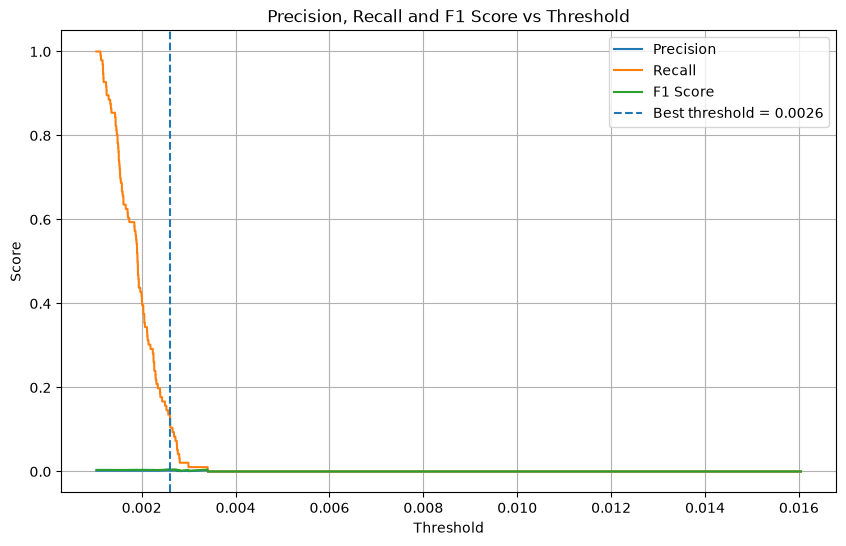

In [22]:
data = df[
    ["amount", "sender_age_group", "hour_of_day", "day_of_week", "fraud_flag"]
]

X = data[
    ["amount", "sender_age_group", "hour_of_day", "day_of_week"]
]

y = data["fraud_flag"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

encoder.fit(
    X_train[["sender_age_group", "day_of_week"]]
)

X_train_encoded = encoder.transform(
    X_train[["sender_age_group", "day_of_week"]]
)

X_test_encoded = encoder.transform(
    X_test[["sender_age_group", "day_of_week"]]
)


X_train_numeric = X_train[
    ["amount", "hour_of_day"]
]

X_test_numeric = X_test[
    ["amount", "hour_of_day"]
]

from scipy.sparse import hstack

X_train_final = hstack([
    X_train_numeric,
    X_train_encoded
])

X_test_final = hstack([
    X_test_numeric,
    X_test_encoded
])

print("X_train shape:", X_train_final.shape)
print("X_test shape :", X_test_final.shape)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train_final,
    y_train
)

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)


y_predicted_probability = model.predict_proba(
    X_test_final
)[:, 1]

print("\nFirst 5 fraud probabilities:")
print(y_predicted_probability[:5])

y_pred_default = (
    y_predicted_probability >= 0.5
).astype(int)

from sklearn.metrics import confusion_matrix

cm_default = confusion_matrix(
    y_test,
    y_pred_default
)

print("\nConfusion Matrix - Threshold 0.5:")
print(cm_default)

from sklearn.metrics import (
    precision_recall_curve,
    f1_score
)

import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_predicted_probability
)

f1_scores = (
    2 * precision * recall
    / (precision + recall + 1e-10)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("\nBest Threshold:")
print(best_threshold)

print("\nBest F1 Score:")
print(f1_scores[best_index])

y_pred_best = (
    y_predicted_probability >= best_threshold
).astype(int)

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nConfusion Matrix - Best Threshold:")
print(cm_best)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred_best
)

precision_best = precision_score(
    y_test,
    y_pred_best,
    zero_division=0
)

recall_best = recall_score(
    y_test,
    y_pred_best,
    zero_division=0
)

f1_best = f1_score(
    y_test,
    y_pred_best,
    zero_division=0
)


print("\n==============================")
print("FINAL MODEL PERFORMANCE")
print("==============================")

print("Threshold :", best_threshold)
print("Accuracy  :", accuracy)
print("Precision :", precision_best)
print("Recall    :", recall_best)
print("F1 Score  :", f1_best)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores[:-1],
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.4f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs Threshold")

plt.legend()
plt.grid()

plt.show()

## Conclusion ##

This analysis explored UPI transaction patterns across time, demographics, merchant categories, banks, devices, networks, and geography, then built a baseline fraud detection model. Transaction activity shows clear patterns by day and hour, spending varies meaningfully by age group and merchant category, and a small number of categories/transaction types account for most of the total value. Cross-bank transactions outnumber in-bank ones, and failures are concentrated in specific device and network types — a signal worth investigating further for reliability improvements. Certain states also contribute disproportionately to total transaction value. The logistic regression fraud model provides a reasonable working baseline, with threshold tuning improving the precision-recall tradeoff, but class imbalance and more advanced models should be explored before using it for real decision-making.